In [1]:
!git clone -b Nidhi https://github.com/cs59300-deep-learning/nisar-flood-mapping.git
%cd nisar-flood-mapping
!git log --oneline -3

Cloning into 'nisar-flood-mapping'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 111 (delta 32), reused 90 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 38.61 MiB | 18.83 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/nisar-flood-mapping
b971ccb (HEAD -> Nidhi, origin/Nidhi) feat(datasets): add check command to verify Sen1Floods11 splits and value ranges (#17)
af65098 feat(datasets): add Sen1Floods11 preprocessing, download and dataloader (#17)
4978654 (origin/main, origin/HEAD) Merge pull request #39 from cs59300-deep-learning/chore/scaffold-repo-structure


In [2]:
!pip install -q rasterio

In [3]:
import sys
sys.path.insert(0, "src")
from nisar_flood.datasets.sen1floods11 import SPLITS, EXPECTED
print(list(SPLITS), EXPECTED)

['train', 'val', 'test', 'bolivia'] {'train': 252, 'val': 89, 'test': 90, 'bolivia': 15}


In [4]:
import requests
from nisar_flood.datasets.sen1floods11 import BASE

url = f"{BASE}/splits/flood_handlabeled/flood_train_data.csv"
r = requests.get(url, timeout=30)
print(r.status_code)
print(r.text[:300])

200
Ghana_103272_S1Hand.tif,Ghana_103272_LabelHand.tif
Ghana_24858_S1Hand.tif,Ghana_24858_LabelHand.tif
Ghana_147015_S1Hand.tif,Ghana_147015_LabelHand.tif
Ghana_953791_S1Hand.tif,Ghana_953791_LabelHand.tif
Ghana_154838_S1Hand.tif,Ghana_154838_LabelHand.tif
Ghana_134751_S1Hand.tif,Ghana_134751_Label


In [5]:
!PYTHONPATH=src python -m nisar_flood.datasets.sen1floods11 download

train: 100% 252/252 [10:30<00:00,  2.50s/it]
val: 100% 89/89 [03:26<00:00,  2.32s/it]
test: 100% 90/90 [03:24<00:00,  2.28s/it]
bolivia: 100% 15/15 [00:37<00:00,  2.49s/it]


In [6]:
!PYTHONPATH=src python -m nisar_flood.datasets.sen1floods11 check

OK    train    n=252 (expected 252) missing=0 water=9.5%
OK    val      n= 89 (expected 89) missing=0 water=11.0%
OK    test     n= 90 (expected 90) missing=0 water=12.5%
OK    bolivia  n= 15 (expected 15) missing=0 water=15.9%


In [7]:
!du -sh data/sen1floods11

700M	data/sen1floods11


Ghana_103272_S1Hand.tif | shape (2, 512, 512) | bands: ('VV', 'VH')
VV: min -39.3  max 8.6  mean -9.2  NaNs: 0
VH: min -47.4  max -1.4  mean -15.2  NaNs: 0


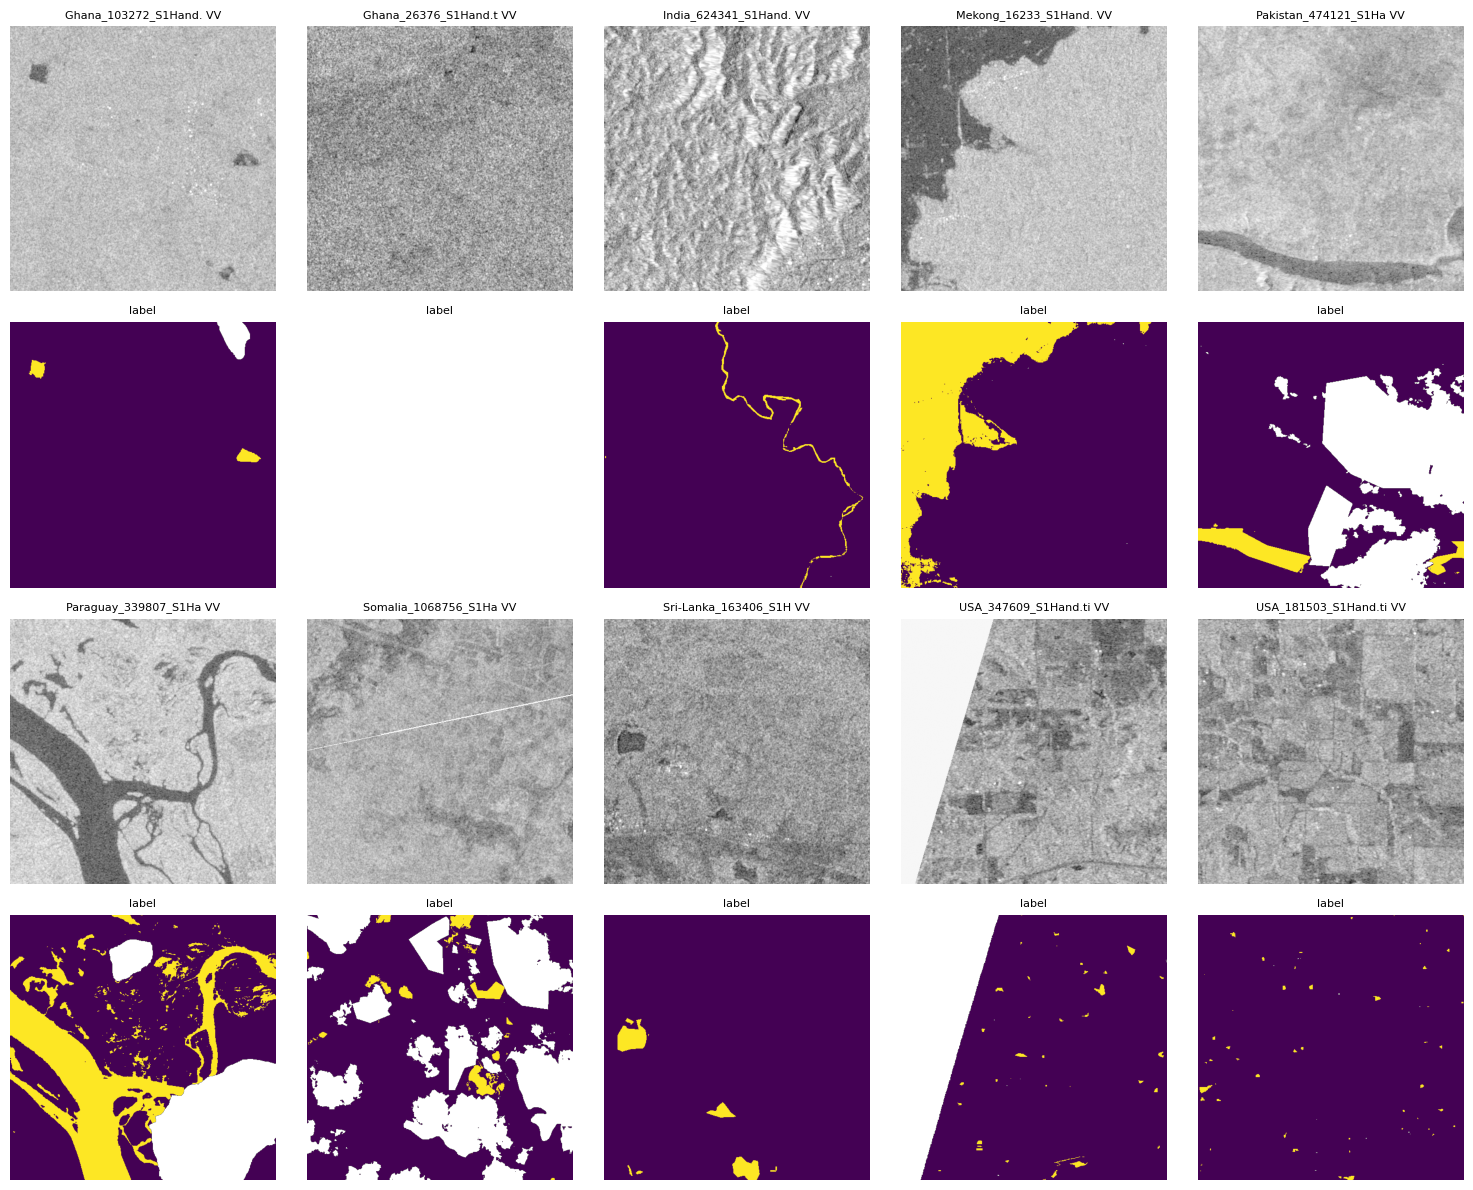

In [8]:
import numpy as np, rasterio, matplotlib.pyplot as plt
from nisar_flood.datasets.sen1floods11 import Sen1Floods11
from nisar_flood.datasets.transforms import IGNORE_INDEX

root = "data/sen1floods11"
ds = Sen1Floods11(root, "train")

# 1) raw values of one chip, before any preprocessing
name = ds.rows[0][0]
with rasterio.open(f"{root}/data/S1Hand/{name}") as f:
    raw = f.read().astype("float32")
    print(name, "| shape", raw.shape, "| bands:", f.descriptions)
for b, band in zip(["VV", "VH"], raw):
    print(f"{b}: min {np.nanmin(band):.1f}  max {np.nanmax(band):.1f}  mean {np.nanmean(band):.1f}  NaNs: {int(np.isnan(band).sum())}")

# 2) 10 training chips: VV image, and the label beneath it
idx = np.linspace(0, len(ds) - 1, 10, dtype=int)
fig, ax = plt.subplots(4, 5, figsize=(15, 12))
for k, i in enumerate(idx):
    x, y = ds[i]
    lab = y.numpy().astype(float); lab[lab == IGNORE_INDEX] = np.nan
    r, c = (k // 5) * 2, k % 5
    ax[r, c].imshow(x[0], cmap="gray");  ax[r, c].set_title(ds.rows[i][0][:20] + " VV", fontsize=8)
    ax[r + 1, c].imshow(lab, cmap="viridis", vmin=0, vmax=1); ax[r + 1, c].set_title("label", fontsize=8)
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

In [9]:
empty = []
for i in range(len(ds)):
    _, y = ds[i]
    if (y != IGNORE_INDEX).sum() == 0:
        empty.append(ds.rows[i][0])
print(len(empty), "of", len(ds), "train chips have no valid label pixels")
print(empty[:5])

1 of 252 train chips have no valid label pixels
['Ghana_26376_S1Hand.tif']
